In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor, plot_importance
import matplotlib.pyplot as plt

In [2]:
weekly = pd.read_csv('player_weekly_data_2014_24.csv') 
weekly = weekly[['player_id', 'game_id', 'receiving_yards']]
print(weekly.columns)
last5 = pd.read_csv('player_last5_avg_2014-24.csv') #player_id, season, week, game_id, opponent_team
print(last5.shape)
season = pd.read_csv('player_season_avg_2014-24.csv') #player_id, season, week, game_id, opponent_team
print(season.shape)
defenseL5 = pd.read_csv('team_defense_last5_avg_2014_24.csv') #game_id, opponent_team
print(defenseL5.shape)
defenseSeason = pd.read_csv('team_defense_season_avg_2014-24.csv') #game_id, opponent_team
print(defenseSeason.shape)
offenseL5 = pd.read_csv('team_offense_last5_avg_2014_24.csv') #game_id, ball_team
print(offenseL5.shape)
offenseSeason = pd.read_csv('team_offense_season_avg_2014-24.csv') #game_id, ball_team
offenseSeason = offenseSeason[['ball_team', 'season', 'game_id', 'rn', 'completions_season_avg', 'attempts_season_avg',
                               'passing_yards_season_avg', 'passing_tds_season_avg', 'carries_season_avg','rushing_yards_season_avg', 'rushing_tds_season_avg',
                               'receptions_season_avg', 'targets_season_avg', 'receiving_yards_season_avg', 'receiving_tds_season_avg']]
print(offenseSeason.shape)
career = pd.read_csv('player_career_avg_2014-24.csv')
career = career.drop(columns=['recent_team', 'player_display_name', 'position', 'season', 'week', 'opponent_team', 'ball_team'])
print(career.columns)

Index(['player_id', 'game_id', 'receiving_yards'], dtype='object')
(57301, 23)
(57301, 23)
(5758, 19)
(5758, 12)
(5758, 24)
(5758, 15)
Index(['player_id', 'game_id', 'rn', 'completions_career', 'attempts_career',
       'passing_yards_career', 'passing_tds_career', 'interceptions_career',
       'carries_career', 'rushing_yards_career', 'rushing_tds_career',
       'receptions_career', 'targets_career', 'receiving_yards_career',
       'receiving_tds_career', 'fumbles_lost_career'],
      dtype='object')


In [3]:
all_players = last5.merge(season[['player_id', 'season', 'week', 'game_id', 'opponent_team', 'rn',
                                  'completions_season_avg','attempts_season_avg', 'passing_yards_season_avg',
                                  'passing_tds_season_avg', 'interceptions_season_avg',
                                  'carries_season_avg', 'rushing_yards_season_avg',
                                  'rushing_tds_season_avg', 'receptions_season_avg', 'targets_season_avg',
                                  'receiving_yards_season_avg', 'receiving_tds_season_avg',
                                  'fumbles_lost_season_avg']],
                          on=['player_id', 'season', 'week', 'game_id', 'opponent_team', 'rn'], how='inner')
all_players = all_players.merge(weekly, on=['player_id', 'game_id'], how='inner')
print(all_players.shape)
dl5 = defenseL5.rename(columns={'receiving_yards': 'def_rec_yds', 'receiving_tds': 'def_rec_tds',
                                 'rushing_yards': 'def_rush_yds', 'rushing_tds': 'def_rush_tds',
                                 'passing_yards': 'def_pass_yds', 'passing_tds': 'def_pass_tds',
                                 'interceptions': 'def_int', 'fumbles_lost': 'def_fumbles',
                                 'receiving_yards_last5': 'def_rec_yds_l5', 'receiving_tds_last5': 'def_rec_tds_l5',
                                 'rushing_yards_last5': 'def_rush_yds_l5', 'rushing_tds_last5': 'def_rush_tds_l5',
                                 'passing_yards_last5': 'def_pass_yds_l5', 'passing_tds_last5': 'def_pass_tds_l5',
                                 'interceptions_last5': 'def_int_l5', 'fumbles_lost_last5': 'def_fumbles_l5'})
all_dl5 = all_players.merge(dl5, on=['game_id', 'opponent_team'], how='inner')
print(all_dl5.shape)
ol5 = offenseL5.rename(columns={'receiving_yards': 'off_rec_yds', 'receiving_tds': 'off_rec_tds', 'receptions': 'off_rec',
                                 'rushing_yards': 'off_rush_yds', 'rushing_tds': 'off_rush_tds', 'carries': 'off_car',
                                 'passing_yards': 'off_pass_yds', 'passing_tds': 'off_pass_tds', 'completions': 'off_comp', 'attempts': 'off_att',
                                 'interceptions': 'off_int', 'fumbles_lost': 'off_fumbles',
                                 'receiving_yards_last5': 'off_rec_yds_l5', 'receiving_tds_last5': 'off_rec_tds_l5', 'receptions_last5': 'off_rec_l5',
                                 'rushing_yards_last5': 'off_rush_yds_l5', 'rushing_tds_last5': 'off_rush_tds_l5', 'carries_last5': 'off_car_l5',
                                 'passing_yards_last5': 'off_pass_yds_l5', 'passing_tds_last5': 'off_pass_tds_l5', 'completions_last5': 'off_comp_l5', 'attempts_last5': 'off_att_l5',
                                 'interceptions_last5': 'off_int_l5', 'fumbles_lost_last5': 'off_fumbles_l5'})
all_ol5 = all_dl5.merge(ol5, on=['game_id', 'ball_team'], how='inner')
print(all_ol5.shape)
ds = defenseSeason.rename(columns={'passing_yards_season_avg': 'def_pass_yds_s', 'passing_tds_season_avg': 'def_pass_tds_s', 'interceptions_season_avg': 'def_int_s',
                                   'rushing_yards_season_avg': 'def_rush_yds_s', 'rushing_tds_season_avg': 'def_rush_tds_s', 'fumbles_lost_season_avg': 'def_fbl_s',
                                   'receiving_yards_season_avg': 'def_rec_yds_s', 'receiving_tds_season_avg': 'def_rec_tds_s'})
all_ds = all_ol5.merge(ds, on=['game_id', 'opponent_team'], how='inner')
print(all_ds.shape)
os = offenseSeason.rename(columns={'completions_season_avg': 'off_comp_s', 'attempts_season_avg': 'off_att_s',
                                   'passing_yards_season_avg': 'off_pass_yds_s', 'passing_tds_season_avg': 'off_pass_tds_s', 'interceptions_season_avg': 'off_int_s',
                                   'carries_season_avg':'off_car_s','rushing_yards_season_avg': 'off_rush_yds_s', 'rushing_tds_season_avg': 'off_rush_tds_s', 'fumbles_lost_season_avg': 'off_fbl_s',
                                   'targets_season_avg':'off_tgt_s','receptions_season_avg': 'off_rec_s', 'receiving_yards_season_avg': 'off_rec_yds_s', 'receiving_tds_season_avg': 'off_rec_tds_s'
})
all_os = all_ds.merge(os, on=['game_id', 'ball_team'], how='inner')
print(all_os.shape)
data = all_os.merge(career, on=['game_id', 'player_id'], how='inner')
print(data.shape)
print(data.columns)

(57301, 37)
(57301, 54)
(57301, 76)
(57301, 86)


C:\Users\rille\AppData\Local\Temp\ipykernel_18308\1934284094.py:34: FutureWarning: Passing 'suffixes' which cause duplicate columns {'rn_x'} in the result is deprecated and will raise a MergeError in a future version.
  all_ds = all_ol5.merge(ds, on=['game_id', 'opponent_team'], how='inner')
C:\Users\rille\AppData\Local\Temp\ipykernel_18308\1934284094.py:43: FutureWarning: Passing 'suffixes' which cause duplicate columns {'rn_x'} in the result is deprecated and will raise a MergeError in a future version.
  data = all_os.merge(career, on=['game_id', 'player_id'], how='inner')


(57301, 99)
(57301, 113)
Index(['player_id', 'recent_team', 'player_display_name', 'position',
       'season_x', 'week', 'opponent_team', 'game_id', 'ball_team', 'rn_x',
       ...
       'passing_tds_career', 'interceptions_career', 'carries_career',
       'rushing_yards_career', 'rushing_tds_career', 'receptions_career',
       'targets_career', 'receiving_yards_career', 'receiving_tds_career',
       'fumbles_lost_career'],
      dtype='object', length=113)


Select the columns to include in the model

In [4]:
#Receiving yards <- objective
data_f = data[['position', 'receiving_yards',
       'targets_last5', 'receiving_yards_last5', 'receiving_tds_last5','fumbles_lost_last5',
       'receptions_season_avg', 'targets_season_avg','receiving_yards_season_avg',
       'receiving_tds_season_avg', 'carries_season_avg',
       'receptions_career', 'targets_career', 'receiving_yards_career', 
       'receiving_tds_career', 'fumbles_lost_career',
       
       'def_rec_yds_l5',
       'def_rec_tds_l5', 'def_fumbles_l5','def_int_l5',
       'def_rush_yds_l5', 'def_rush_tds_l5', 'def_int_s', 'def_rush_yds_s',
       'def_rush_tds_s', 
       'def_rec_yds_s', 
       'def_rec_tds_s', 'def_fbl_s',
       
       'off_rush_yds_l5','off_rush_tds_l5', 'off_rec_tds_l5', 'off_car_l5',
       'off_rec_yds_l5', 
       'off_comp_l5', 'off_att_l5', 'off_rec_l5','off_car_s', 'off_rush_yds_s', 'off_rush_tds_s',
       'off_rec_s', 'off_tgt_s', 'off_rec_tds_s',
       'off_rec_yds_s']]
wrs = data_f[data_f['position'] == 'WR']
wrs = wrs[wrs['targets_career'] > 3]
wrs = wrs[wrs['receiving_yards_career'] > 15]
wrs = wrs[wrs['receptions_season_avg'] > 2]
print(wrs.shape)

(6634, 43)


Model

Train MSE: 473.7923181605373
Train MAE: 15.119054296344974
Train R²: 0.5191989110263653
Test MSE: 614.2453806056501
Test MAE: 16.95907629439362
Test R²: 0.3671678385665431


<Figure size 1000x800 with 0 Axes>

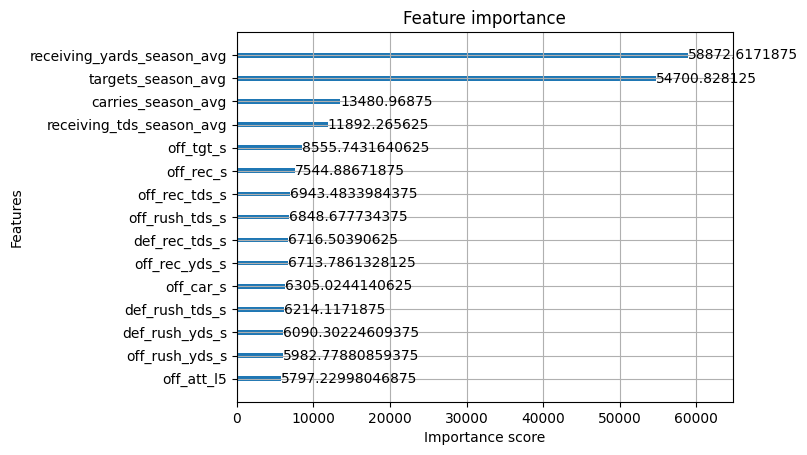

In [6]:


# 1. Definir features y target
features = ['receiving_yards_last5', 'targets_last5', 
            'receptions_season_avg', 'receiving_yards_season_avg',
            'receptions_career', 'receiving_yards_career', 
            'def_rec_yds_l5', 'def_rec_yds_s',
            'off_rec_yds_l5', 'off_rec_yds_s'
            
            ,'receiving_tds_last5', 'fumbles_lost_last5',
            'targets_season_avg', 'receiving_tds_season_avg', 'carries_season_avg',
            'targets_career', 'receiving_tds_career', 'fumbles_lost_career',
             
            'def_rec_tds_l5', 'def_fumbles_l5','def_int_l5','def_rush_yds_l5', 'def_rush_tds_l5',
            'def_int_s', 'def_rush_yds_s', 'def_rush_tds_s',  'def_rec_tds_s', 'def_fbl_s',
             
            'off_rush_yds_l5','off_rush_tds_l5', 'off_rec_tds_l5', 'off_car_l5','off_comp_l5', 'off_att_l5', 'off_rec_l5',
            'off_car_s', 'off_rush_yds_s', 'off_rush_tds_s','off_rec_s', 'off_tgt_s', 'off_rec_tds_s'
            ]

X = data_f[features]
y = data['receiving_yards']

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Entrenar modelo
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# 4. Predicciones
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 5. Métricas
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Train R²:", r2_score(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred))
print("Test R²:", r2_score(y_test, y_test_pred))

# 6. Importancia de features
plt.figure(figsize=(10,8))
plot_importance(model, max_num_features=15, importance_type='gain')
plt.show()